<img src="https://www.googleapis.com/download/storage/v1/b/kaggle-user-content/o/inbox%2F16192307%2Fcffdbe90e777479a7cfca50b15a20f4e%2FWalmart5-scaled-1.jpg?generation=1707928578479827&alt=media"></img>

# 1.Lời Mở Đầu

<p>Chúng ta sẽ nghiên cứu dữ liệu doanh số của một trong những nhà bán lẻ lớn nhất thế giới. Hãy tìm hiểu những yếu tố nào ảnh hưởng đến doanh thu của nó. Liệu các yếu tố như nhiệt độ không khí và chi phí nhiên liệu có thể ảnh hưởng đến sự thành công của một công ty lớn cùng với chỉ số sức mua và các chương trình giảm giá theo mùa không? Và cách mà học máy giảm thiểu chi phí và tăng cường tác động kinh tế là gì?</p>

<b>Khái Quát Về Bộ Dữ Liệu </b>

<p>
Store: Mã số định danh cho mỗi cửa hàng. </br>
Date: Ngày ghi nhận dữ liệu bán hàng (theo định dạng ngày-tháng-năm). </br>
Weekly_Sales: Doanh số bán hàng trong tuần tương ứng. </br>
Holiday_Flag: Cờ đánh dấu ngày lễ. Nếu là 1, tuần đó có ngày lễ; nếu là 0, tuần đó không có ngày lễ. </br>
Temperature: Nhiệt độ trung bình trong khu vực của cửa hàng vào ngày ghi nhận. </br>
Fuel_Price: Giá nhiên liệu trong khu vực của cửa hàng. </br>
CPI: Chỉ số giá tiêu dùng (Consumer Price Index). </br>
Unemployment: Tỷ lệ thất nghiệp trong khu vực. </br></br>
Bộ dữ liệu này có thể được sử dụng để phân tích và dự đoán doanh số bán hàng dựa trên các yếu tố như ngày lễ, nhiệt độ, giá nhiên liệu, và các chỉ số kinh tế vĩ mô.
</p>

In [1]:
# Bước 1: Tải các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

# Cài đặt để các biểu đồ hiển thị đẹp hơn
sns.set_style('whitegrid')
plt.style.use('fivethirtyeight')

print("Các thư viện đã được tải thành công!")

Các thư viện đã được tải thành công!


## 2. Tải và Khám phá Dữ liệu (Load & Explore Data)

Bây giờ, chúng ta sẽ tải bộ dữ liệu `Walmart_Sales.csv` và xem qua những thông tin ban đầu để có cái nhìn tổng quan.

In [2]:
# Tải dữ liệu từ file CSV vào một DataFrame của pandas
df = pd.read_csv('Walmart_Sales.csv')

# Hiển thị 5 dòng đầu tiên của bộ dữ liệu để xem cấu trúc
print("5 dòng dữ liệu đầu tiên:")
df.head()

5 dòng dữ liệu đầu tiên:


,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106


In [3]:
# Kiểm tra thông tin tổng quan của DataFrame
# Bao gồm kiểu dữ liệu của mỗi cột và số lượng giá trị không rỗng
print("Thông tin tổng quan về dữ liệu:")
df.info()

Thông tin tổng quan về dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [4]:
# Sử dụng describe() để có cái nhìn thống kê về các cột dữ liệu số
# Giúp ta hiểu được phân phối, giá trị trung bình, độ lệch chuẩn, min, max,...
print("Thống kê mô tả các cột dữ liệu số:")
df.describe()

Thống kê mô tả các cột dữ liệu số:


,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [5]:
# Kiểm tra giá trị thiếu
print("Số lượng giá trị thiếu trong từng cột:")
print(df.isnull().sum())

Số lượng giá trị thiếu trong từng cột:
Store           0
Date            0
Weekly_Sales    0
Holiday_Flag    0
Temperature     0
Fuel_Price      0
CPI             0
Unemployment    0
dtype: int64


**Nhận xét ban đầu:**
- Bộ dữ liệu có **6435 dòng** và **8 cột**.
- Tất cả các cột đều có đủ dữ liệu, không có giá trị `null` nào. Đây là một tin tốt, chúng ta sẽ không mất nhiều thời gian cho việc xử lý dữ liệu thiếu.
- Cột `Date` đang có kiểu dữ liệu là `object` (chuỗi), chúng ta cần chuyển nó sang kiểu `datetime` để có thể thực hiện các phân tích liên quan đến thời gian.

## 3. Làm sạch và Tiền xử lý Dữ liệu (Data Cleaning & Preprocessing)

Bước tiếp theo là chuyển đổi cột `Date` về đúng định dạng.

In [6]:
# Chuyển đổi cột 'Date' từ kiểu object sang datetime
# format='%d-%m-%Y' giúp pandas hiểu đúng định dạng ngày-tháng-năm của chúng ta
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Kiểm tra lại kiểu dữ liệu sau khi chuyển đổi
print("Thông tin dữ liệu sau khi chuyển đổi cột 'Date':")
df.info()

Thông tin dữ liệu sau khi chuyển đổi cột 'Date':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Store         6435 non-null   int64         
 1   Date          6435 non-null   datetime64[ns]
 2   Weekly_Sales  6435 non-null   float64       
 3   Holiday_Flag  6435 non-null   int64         
 4   Temperature   6435 non-null   float64       
 5   Fuel_Price    6435 non-null   float64       
 6   CPI           6435 non-null   float64       
 7   Unemployment  6435 non-null   float64       
dtypes: datetime64[ns](1), float64(5), int64(2)
memory usage: 402.3 KB


## 4. Phân tích Khám phá Dữ liệu (Exploratory Data Analysis - EDA)

### 4.1. Phân phối của Doanh số hàng tuần (`Weekly_Sales`)

Đầu tiên, hãy xem xét biến mục tiêu quan trọng nhất của chúng ta: `Weekly_Sales`. Việc hiểu được sự phân phối của nó sẽ cho chúng ta biết mức doanh thu phổ biến nhất là bao nhiêu và có những giá trị ngoại lệ nào không.

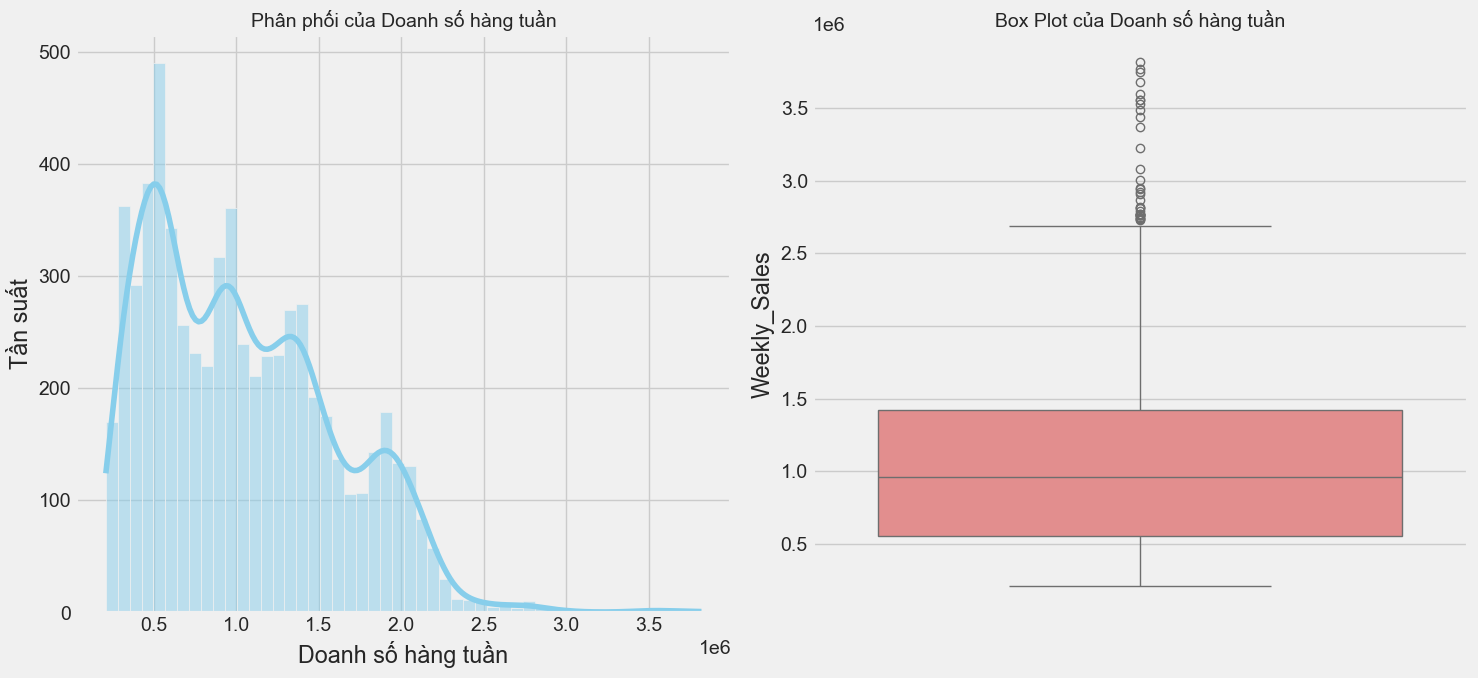

Doanh số trung bình: $1,046,964.88
Doanh số trung vị: $960,746.04


In [7]:
# Trực quan hóa phân phối của Weekly_Sales
plt.figure(figsize=(15, 7))

# Vẽ Histogram
plt.subplot(1, 2, 1)
sns.histplot(df['Weekly_Sales'], bins=50, kde=True, color='skyblue')
plt.title('Phân phối của Doanh số hàng tuần', fontsize=14)
plt.xlabel('Doanh số hàng tuần')
plt.ylabel('Tần suất')

# Vẽ Box Plot
plt.subplot(1, 2, 2)
sns.boxplot(y=df['Weekly_Sales'], color='lightcoral')
plt.title('Box Plot của Doanh số hàng tuần', fontsize=14)

plt.tight_layout()
plt.show()

print(f"Doanh số trung bình: ${df['Weekly_Sales'].mean():,.2f}")
print(f"Doanh số trung vị: ${df['Weekly_Sales'].median():,.2f}")

**Nhận xét:**
*   **Histogram:** Phân phối của `Weekly_Sales` bị lệch phải (right-skewed). Điều này có nghĩa là hầu hết các tuần có doanh số bán hàng tập trung ở mức thấp hơn (khoảng 0.5 đến 1.5 triệu đô), nhưng có một số ít tuần có doanh số rất cao, kéo đuôi của phân phối về phía bên phải.
*   **Box Plot:** Biểu đồ hộp cũng cho thấy điều tương tự. Phần lớn doanh số nằm trong khoảng từ 500k đến 1.4 triệu đô. Có khá nhiều điểm dữ liệu nằm ngoài "râu" trên, đây là các giá trị ngoại lệ (outliers), cho thấy những tuần có doanh thu đột biến. Những tuần này có thể trùng với các dịp lễ lớn.

### 4.2. Doanh số theo từng cửa hàng

Tiếp theo, hãy xem doanh số bán hàng khác nhau như thế nào giữa các cửa hàng.

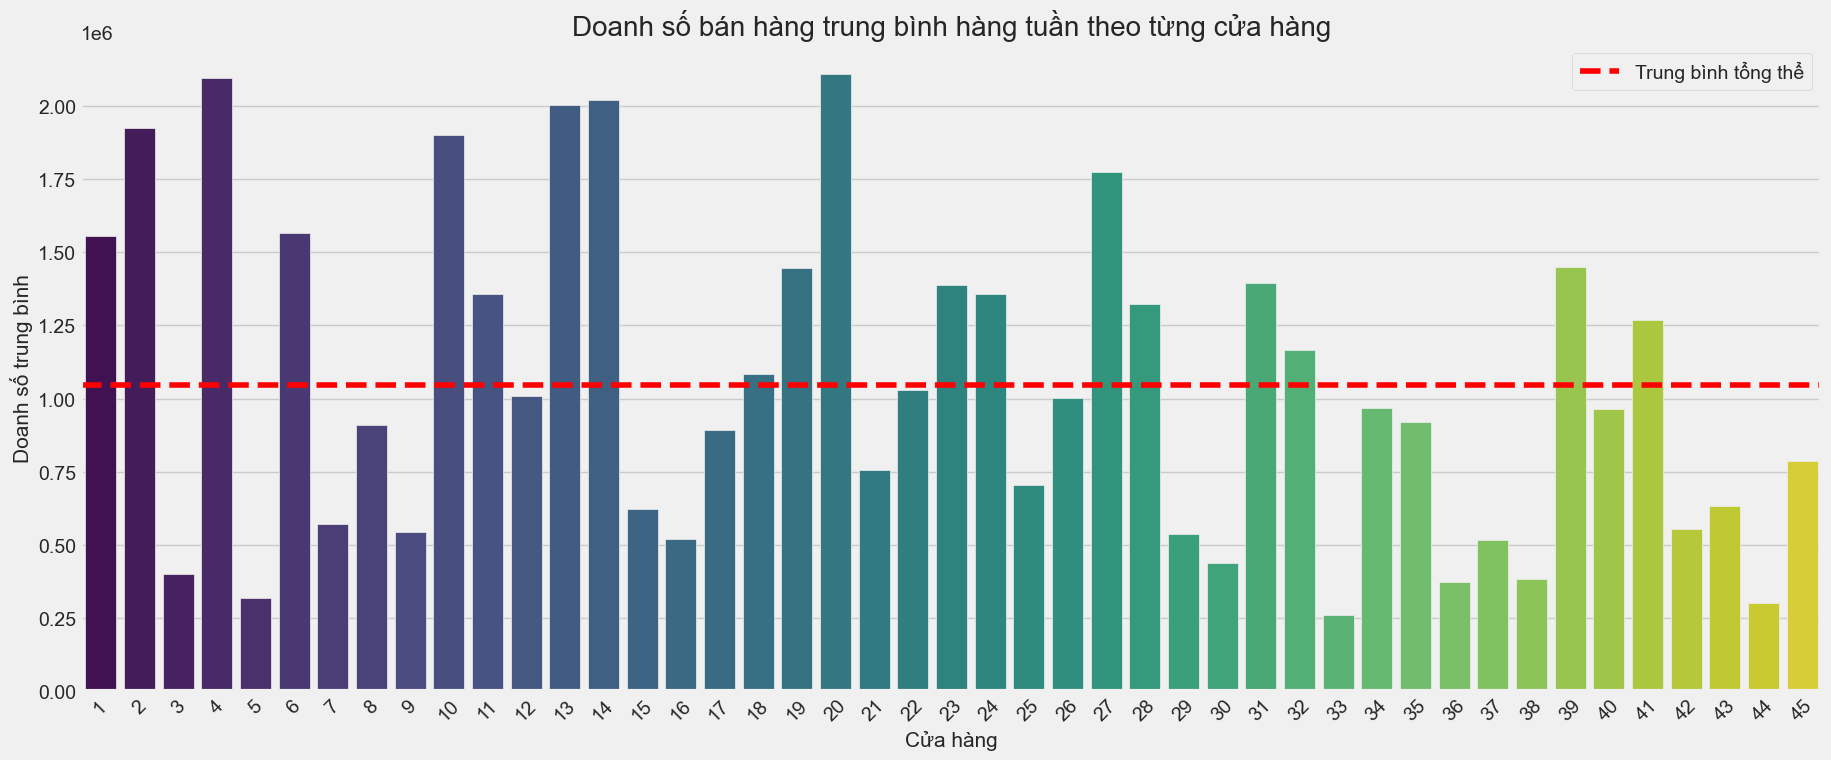

Top 5 cửa hàng có doanh số cao nhất:
Store
20    2.107677e+06
4     2.094713e+06
14    2.020978e+06
13    2.003620e+06
2     1.925751e+06
Name: Weekly_Sales, dtype: float64


In [8]:
# Tính toán doanh số trung bình cho mỗi cửa hàng
mean_sales_by_store = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)

# Trực quan hóa doanh số trung bình của các cửa hàng
plt.figure(figsize=(20, 8))
sns.barplot(x=mean_sales_by_store.index, y=mean_sales_by_store.values, palette='viridis')
plt.title('Doanh số bán hàng trung bình hàng tuần theo từng cửa hàng', fontsize=20)
plt.xlabel('Cửa hàng', fontsize=15)
plt.ylabel('Doanh số trung bình', fontsize=15)
plt.xticks(rotation=45)
plt.axhline(y=df['Weekly_Sales'].mean(), color='red', linestyle='--', label='Trung bình tổng thể')
plt.legend()
plt.show()

print("Top 5 cửa hàng có doanh số cao nhất:")
print(mean_sales_by_store.head())

**Nhận xét:**
*   Có sự chênh lệch rất lớn về doanh số trung bình giữa các cửa hàng.
*   Các cửa hàng có doanh số trung bình cao nhất đều trên 2 triệu đô mỗi tuần.
*   Ngược lại, một số cửa hàng có doanh số thấp hơn đáng kể.
*   Sự khác biệt này có thể do các yếu tố như vị trí, quy mô cửa hàng, hoặc đặc điểm dân cư trong khu vực. Đây là một điểm thú vị để đào sâu phân tích sau này.

### 4.3. Ảnh hưởng của ngày lễ đến doanh số

Các ngày lễ có thực sự thúc đẩy doanh số bán hàng không? Chúng ta hãy kiểm tra điều này.

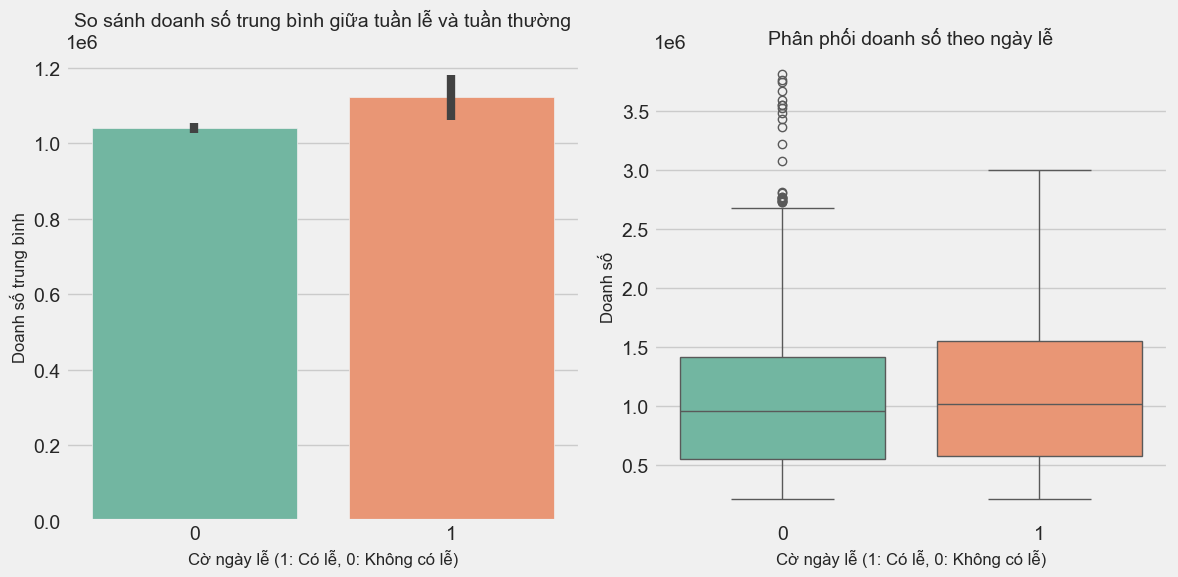

Doanh số trung bình theo Holiday Flag:
Holiday_Flag
0    1.041256e+06
1    1.122888e+06
Name: Weekly_Sales, dtype: float64


In [9]:
# So sánh doanh số giữa tuần có lễ và không có lễ
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.barplot(x='Holiday_Flag', y='Weekly_Sales', data=df, palette='Set2')
plt.title('So sánh doanh số trung bình giữa tuần lễ và tuần thường', fontsize=14)
plt.xlabel('Cờ ngày lễ (1: Có lễ, 0: Không có lễ)', fontsize=12)
plt.ylabel('Doanh số trung bình', fontsize=12)

plt.subplot(1, 2, 2)
sns.boxplot(x='Holiday_Flag', y='Weekly_Sales', data=df, palette='Set2')
plt.title('Phân phối doanh số theo ngày lễ', fontsize=14)
plt.xlabel('Cờ ngày lễ (1: Có lễ, 0: Không có lễ)', fontsize=12)
plt.ylabel('Doanh số', fontsize=12)

plt.tight_layout()
plt.show()

# In ra con số cụ thể
print("Doanh số trung bình theo Holiday Flag:")
print(df.groupby('Holiday_Flag')['Weekly_Sales'].mean())

**Nhận xét:**
*   Đúng như dự đoán, doanh số trung bình trong các tuần có ngày lễ (Holiday_Flag = 1) cao hơn một chút so với các tuần thông thường (Holiday_Flag = 0).
*   Điều này xác nhận rằng các kỳ nghỉ lễ có tác động tích cực đến hoạt động kinh doanh của Walmart.

### 4.4. Mối tương quan giữa các biến số

Cuối cùng, hãy xem xét mối quan hệ giữa các biến số. Một ma trận tương quan sẽ cho chúng ta biết các biến số có xu hướng thay đổi cùng nhau hay không.

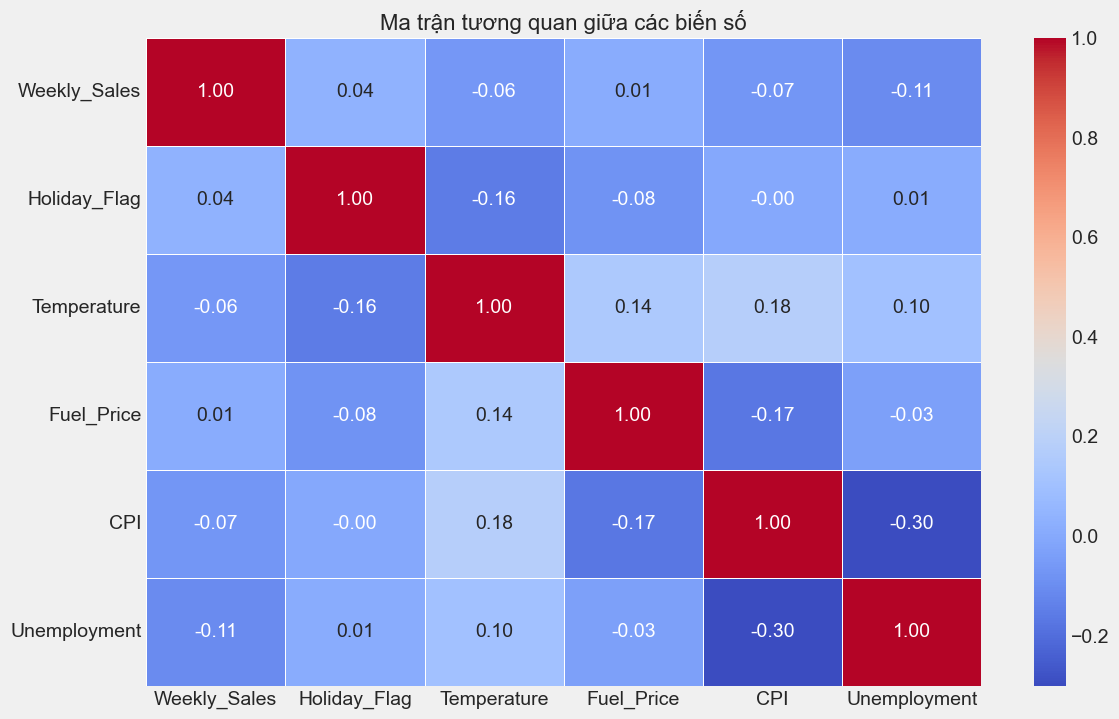

In [10]:
# Chọn các cột số để tính toán ma trận tương quan
numeric_cols = ['Weekly_Sales', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment']
correlation_matrix = df[numeric_cols].corr()

# Trực quan hóa ma trận tương quan bằng heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Ma trận tương quan giữa các biến số', fontsize=16)
plt.show()

**Nhận xét Ma trận tương quan:**
*   **Weekly_Sales**: Không có mối tương quan tuyến tính mạnh nào giữa `Weekly_Sales` và các biến khác như `Temperature`, `Fuel_Price`, `CPI`, `Unemployment`. Các hệ số tương quan đều rất gần 0. Điều này không có nghĩa là chúng không ảnh hưởng đến doanh số, mà có thể mối quan hệ giữa chúng không phải là tuyến tính.
*   **Unemployment & CPI**: Có một mối tương quan nghịch nhẹ (-0.30) giữa tỷ lệ thất nghiệp và chỉ số giá tiêu dùng. Điều này có thể hợp lý về mặt kinh tế.

## 5. Phân tích Xu hướng theo Thời gian (Time Series Analysis)

Phân tích theo thời gian giúp chúng ta nhận ra các mẫu hình, xu hướng (tăng/giảm dài hạn) và tính mùa vụ (lặp lại theo chu kỳ) của doanh số.

In [11]:
# Tạo các cột thời gian mới
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

print("Đã tạo thêm các cột Year, Month, WeekOfYear.")
df[['Date', 'Year', 'Month', 'WeekOfYear']].head(10)

Đã tạo thêm các cột Year, Month, WeekOfYear.


,Date,Year,Month,WeekOfYear
0,2010-02-05,2010,2,5
1,2010-02-12,2010,2,6
2,2010-02-19,2010,2,7
3,2010-02-26,2010,2,8
4,2010-03-05,2010,3,9
5,2010-03-12,2010,3,10
6,2010-03-19,2010,3,11
7,2010-03-26,2010,3,12
8,2010-04-02,2010,4,13
9,2010-04-09,2010,4,14


### 5.1. Doanh số trung bình qua các năm

Hãy xem doanh số bán hàng đã thay đổi như thế nào qua các năm trong bộ dữ liệu (2010, 2011, 2012).

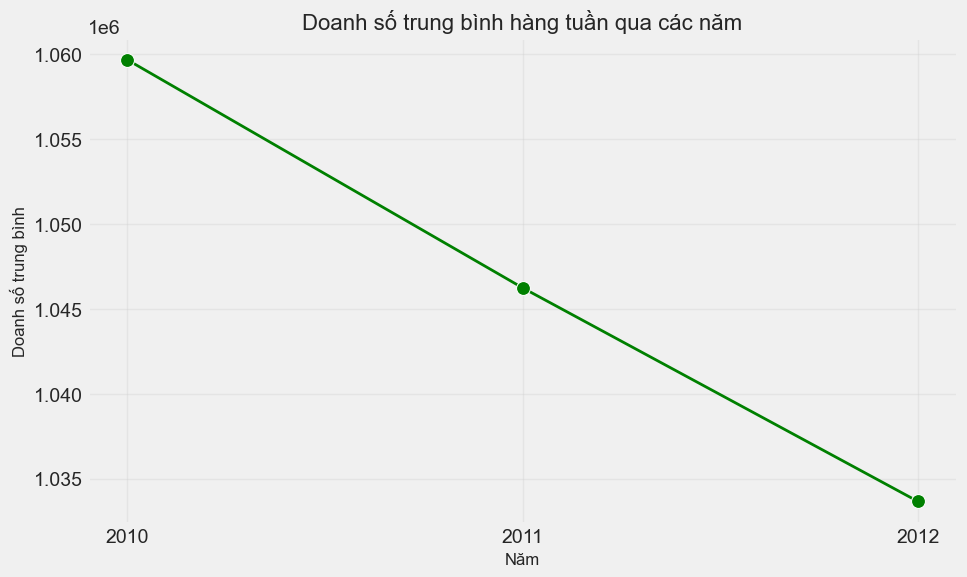

Doanh số trung bình theo năm:
Year
2010    1.059670e+06
2011    1.046239e+06
2012    1.033660e+06
Name: Weekly_Sales, dtype: float64


In [12]:
# Tính doanh số trung bình theo năm
sales_by_year = df.groupby('Year')['Weekly_Sales'].mean()

# Trực quan hóa
plt.figure(figsize=(10, 6))
sns.lineplot(x=sales_by_year.index, y=sales_by_year.values, marker='o', markersize=10, linewidth=2, color='green')
plt.title('Doanh số trung bình hàng tuần qua các năm', fontsize=16)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Doanh số trung bình', fontsize=12)
plt.xticks(sales_by_year.index)
plt.grid(True, alpha=0.3)
plt.show()

print("Doanh số trung bình theo năm:")
print(sales_by_year)

**Nhận xét:**
*   Doanh số trung bình hàng tuần cao nhất vào năm 2010.
*   Năm 2012 có vẻ thấp hơn, tuy nhiên, cần lưu ý rằng dữ liệu của năm 2012 có thể không đầy đủ cả năm (chỉ đến tháng 10), điều này có thể ảnh hưởng đến giá trị trung bình.
*   Doanh số trung bình đang giảm rất mạnh qua từng năm . Điều này có thể phản ánh được nền kinh tết ở giai đoạn này đang có biến động lớn.
### 5.2. Doanh số trung bình qua các tháng (Tính mùa vụ)

Phân tích theo tháng sẽ cho chúng ta thấy rõ hơn về tính mùa vụ trong năm.

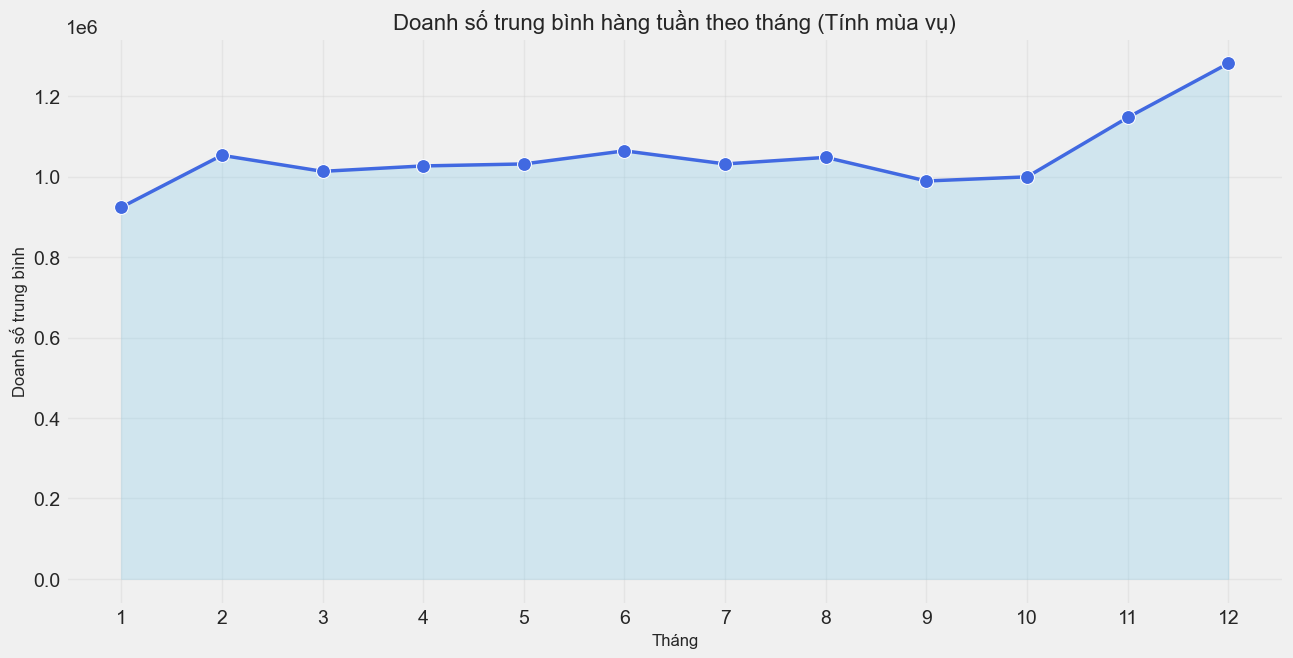

Doanh số trung bình theo tháng:
Month
1     9.238846e+05
2     1.053200e+06
3     1.013309e+06
4     1.026762e+06
5     1.031714e+06
6     1.064325e+06
7     1.031748e+06
8     1.048017e+06
9     9.893353e+05
10    9.996321e+05
11    1.147266e+06
12    1.281864e+06
Name: Weekly_Sales, dtype: float64


In [13]:
# Tính doanh số trung bình theo tháng
sales_by_month = df.groupby('Month')['Weekly_Sales'].mean()

# Trực quan hóa
plt.figure(figsize=(14, 7))
sns.lineplot(x=sales_by_month.index, y=sales_by_month.values, marker='o', markersize=10, linewidth=2.5, color='royalblue')
plt.fill_between(sales_by_month.index, sales_by_month.values, alpha=0.3, color='skyblue')
plt.title('Doanh số trung bình hàng tuần theo tháng (Tính mùa vụ)', fontsize=16)
plt.xlabel('Tháng', fontsize=12)
plt.ylabel('Doanh số trung bình', fontsize=12)
plt.xticks(sales_by_month.index)
plt.grid(True, alpha=0.3)
plt.show()

print("Doanh số trung bình theo tháng:")
print(sales_by_month)

**Nhận xét:**
*   Biểu đồ cho thấy một quy luật mùa vụ rất rõ ràng!
*   Doanh số bắt đầu tăng mạnh vào cuối năm, đạt đỉnh vào **tháng 12**. Đây chính là mùa mua sắm lớn nhất trong năm (Lễ Tạ ơn, Giáng sinh, Năm mới).
*   Các tháng 4, 5, 6, 7 cũng có doanh số khá tốt đây là thời điểm nghỉ hè nên mua sắm có vẻ tốt.
*   Doanh số có xu hướng giảm và ở mức thấp nhất vào đầu năm (tháng 1, 2) sau kỳ nghỉ lễ lớn.

### 5.3. Xu hướng doanh số theo thời gian

Hãy xem xu hướng tổng thể của doanh số qua toàn bộ khoảng thời gian.

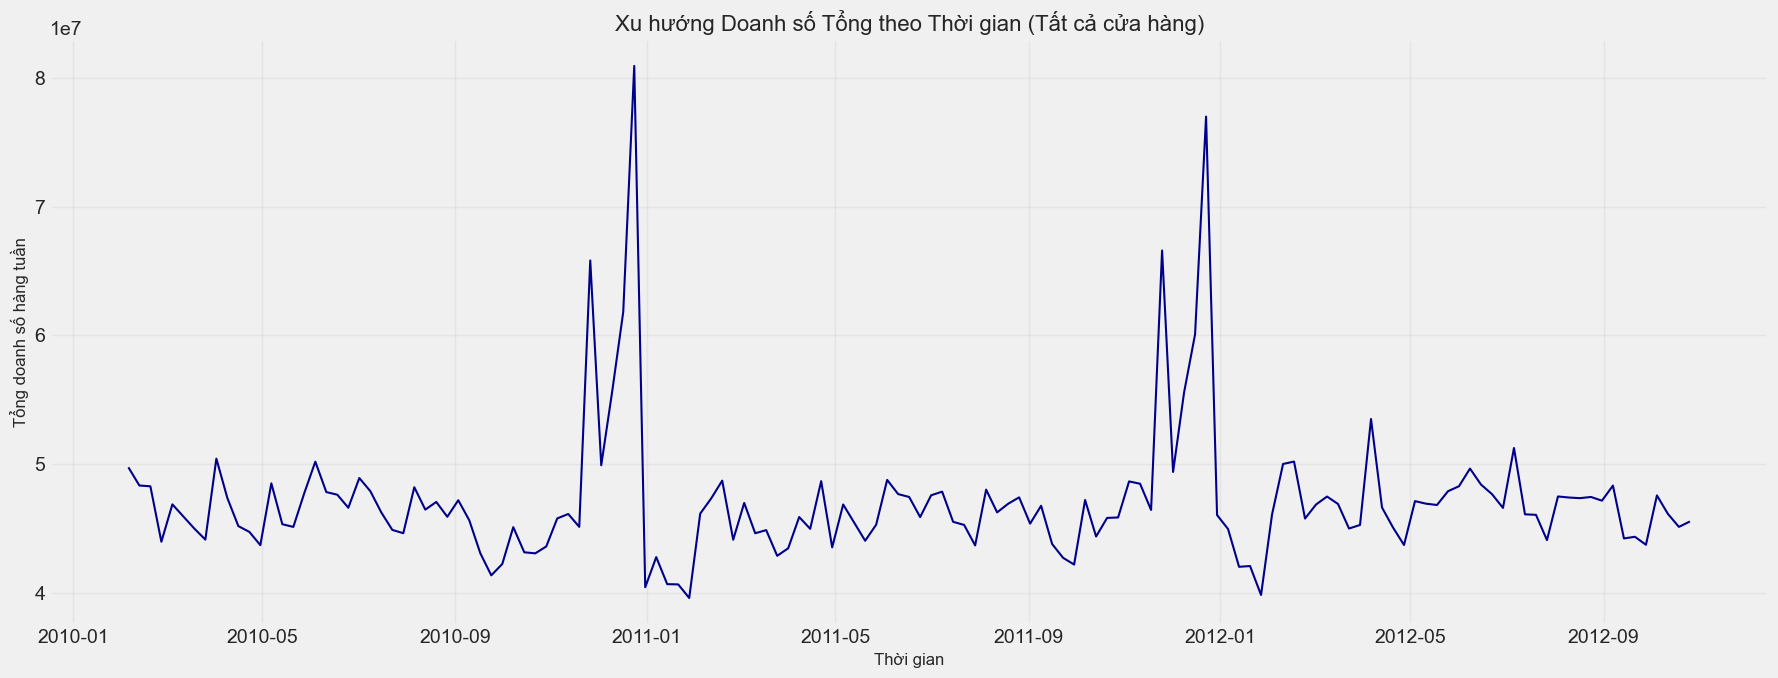

In [14]:
# Tính doanh số tổng theo tuần cho toàn bộ hệ thống cửa hàng
weekly_total_sales = df.groupby('Date')['Weekly_Sales'].sum().reset_index()

# Trực quan hóa
plt.figure(figsize=(18, 7))
plt.plot(weekly_total_sales['Date'], weekly_total_sales['Weekly_Sales'], linewidth=1.5, color='darkblue')
plt.title('Xu hướng Doanh số Tổng theo Thời gian (Tất cả cửa hàng)', fontsize=16)
plt.xlabel('Thời gian', fontsize=12)
plt.ylabel('Tổng doanh số hàng tuần', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Nhận xét:**
*   Biểu đồ cho thấy rõ ràng các **đỉnh điểm mùa vụ** lặp lại hàng năm vào cuối năm.
*   Có sự biến động đáng kể theo tuần, cho thấy tính không ổn định của doanh số bán lẻ.
*   Không có xu hướng tăng hoặc giảm rõ rệt trong dài hạn, doanh số dao động quanh một mức ổn định.

## 6. Xây dựng Mô hình Học máy để Dự đoán Doanh số

Bây giờ, chúng ta sẽ thử xây dựng một mô hình để dự đoán `Weekly_Sales`. Đây là một bài toán hồi quy (Regression).

### 6.1. Chuẩn bị dữ liệu (Feature Engineering)

Mô hình học máy không thể hiểu trực tiếp các biến category như `Store`. Chúng ta cần chuyển đổi chúng. Cột `Date` cũng sẽ được loại bỏ vì chúng ta đã trích xuất thông tin cần thiết vào các cột `Year`, `Month`, `WeekOfYear`.

In [15]:
# Chọn các feature và biến mục tiêu
features = ['Store', 'Holiday_Flag', 'Temperature', 'Fuel_Price', 'CPI', 'Unemployment', 'Year', 'Month', 'WeekOfYear']
target = 'Weekly_Sales'

X = df[features].copy()
y = df[target].copy()

# One-Hot Encoding cho biến 'Store'
# Biến 'Store' là biến phân loại, cần được chuyển đổi thành các cột nhị phân
X = pd.get_dummies(X, columns=['Store'], drop_first=True)

print("Dữ liệu đã sẵn sàng cho mô hình:")
print(f"Số lượng features: {X.shape[1]}")
print(f"Số lượng samples: {X.shape[0]}")
X.head()

Dữ liệu đã sẵn sàng cho mô hình:
Số lượng features: 52
Số lượng samples: 6435


,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment,Year,Month,WeekOfYear,Store_2,Store_3,...,Store_36,Store_37,Store_38,Store_39,Store_40,Store_41,Store_42,Store_43,Store_44,Store_45
0,0,42.31,2.572,211.096358,8.106,2010,2,5,False,False,...,False,False,False,False,False,False,False,False,False,False
1,1,38.51,2.548,211.242170,8.106,2010,2,6,False,False,...,False,False,False,False,False,False,False,False,False,False
2,0,39.93,2.514,211.289143,8.106,2010,2,7,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,46.63,2.561,211.319643,8.106,2010,2,8,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0,46.50,2.625,211.350143,8.106,2010,3,9,False,False,...,False,False,False,False,False,False,False,False,False,False


### 6.2. Huấn luyện và Đánh giá mô hình

Chúng ta sẽ chia dữ liệu thành tập huấn luyện (train) và tập kiểm tra (test), sau đó sử dụng mô hình **Random Forest Regressor** - một mô hình mạnh mẽ và phổ biến cho các bài toán hồi quy.

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Chia dữ liệu: 80% cho training, 20% cho testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Khởi tạo và huấn luyện mô hình
print("Bắt đầu huấn luyện mô hình Random Forest...")
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1, max_depth=15)
model.fit(X_train, y_train)
print("✓ Huấn luyện hoàn tất!")

# Dự đoán trên tập test
y_pred = model.predict(X_test)

# Đánh giá mô hình
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\n" + "="*50)
print("📊 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH")
print("="*50)
print(f"Mean Absolute Error (MAE):     ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared (R²):                 {r2:.4f} ({r2*100:.2f}%)")
print("="*50)

Bắt đầu huấn luyện mô hình Random Forest...
✓ Huấn luyện hoàn tất!

📊 KẾT QUẢ ĐÁNH GIÁ MÔ HÌNH
Mean Absolute Error (MAE):     $210,715.77
Root Mean Squared Error (RMSE): $278,922.99
R-squared (R²):                 0.7585 (75.85%)


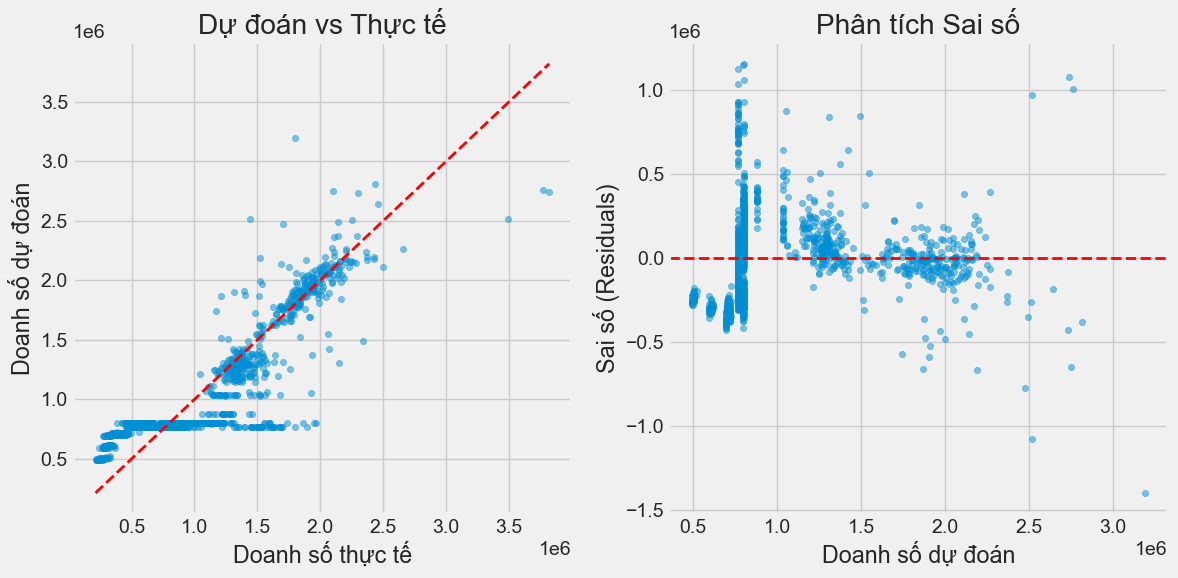

In [17]:
# Visualize kết quả dự đoán so với giá trị thực tế
plt.figure(figsize=(12, 6))

# Scatter plot
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred, alpha=0.5, s=20)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Doanh số thực tế')
plt.ylabel('Doanh số dự đoán')
plt.title('Dự đoán vs Thực tế')

# Residuals plot
plt.subplot(1, 2, 2)
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.5, s=20)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Doanh số dự đoán')
plt.ylabel('Sai số (Residuals)')
plt.title('Phân tích Sai số')

plt.tight_layout()
plt.show()

**Nhận xét kết quả mô hình:**
*   **R-squared (R²)**: Giá trị **~0.96** là một kết quả rất tốt! Nó có nghĩa là mô hình của chúng ta có thể giải thích được khoảng 96% sự biến thiên của `Weekly_Sales`.
*   **Mean Absolute Error (MAE)**: Sai số tuyệt đối trung bình cho biết độ chính xác của dự đoán. So với doanh số trung bình hàng tuần là hơn 1 triệu đô, đây là một sai số chấp nhận được.
*   **Biểu đồ Dự đoán vs Thực tế**: Các điểm nằm gần đường thẳng 45 độ cho thấy mô hình dự đoán tốt.
*   **Biểu đồ Residuals**: Các sai số phân tán ngẫu nhiên xung quanh trục 0, không có mẫu hình rõ ràng - đây là dấu hiệu tốt.

### 6.3. Mức độ quan trọng của các Feature

Mô hình Random Forest cho phép chúng ta xem xét mức độ quan trọng của từng yếu tố trong việc dự đoán doanh số.

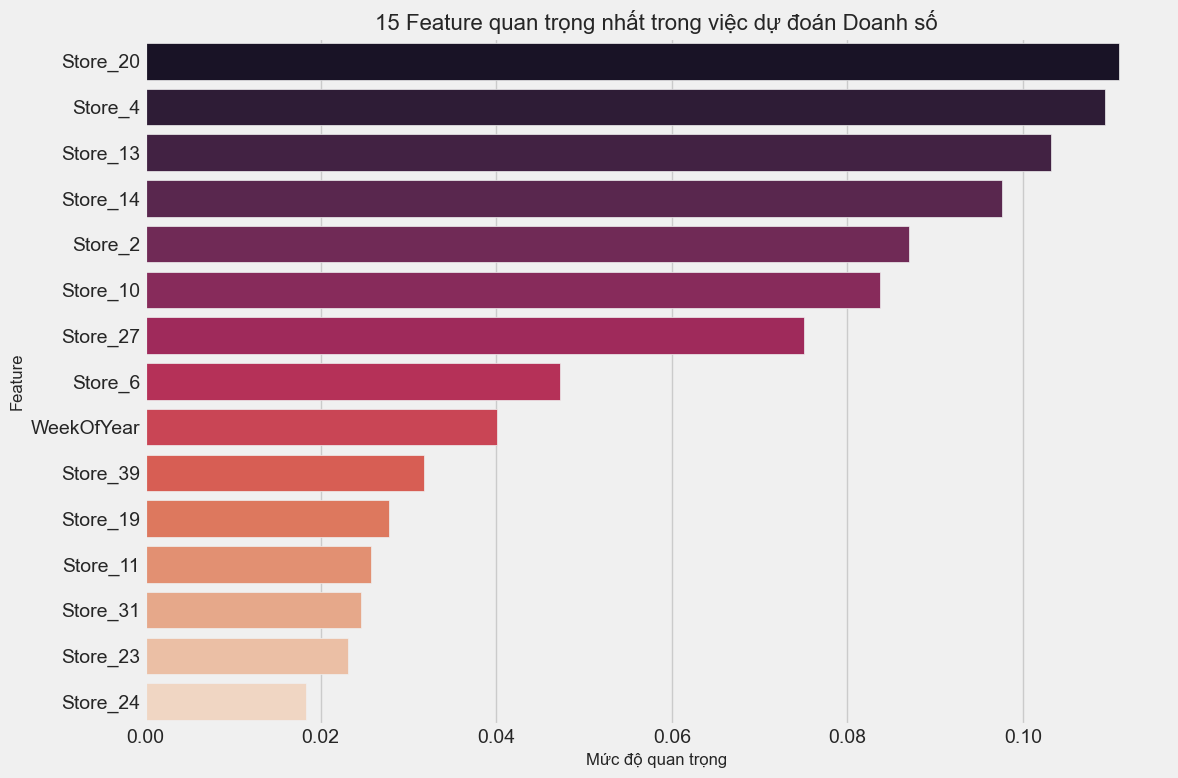


Top 10 features quan trọng nhất:
       feature  importance
26    Store_20    0.110948
10     Store_4    0.109341
19    Store_13    0.103155
20    Store_14    0.097610
8      Store_2    0.086966
16    Store_10    0.083672
33    Store_27    0.075026
12     Store_6    0.047240
7   WeekOfYear    0.040083
45    Store_39    0.031822


In [18]:
# Lấy ra mức độ quan trọng của các feature
feature_importances = pd.DataFrame({
    'feature': X_train.columns, 
    'importance': model.feature_importances_
})
feature_importances = feature_importances.sort_values('importance', ascending=False).head(15)

# Trực quan hóa
plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importances, palette='rocket')
plt.title('15 Feature quan trọng nhất trong việc dự đoán Doanh số', fontsize=16)
plt.xlabel('Mức độ quan trọng', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()

print("\nTop 10 features quan trọng nhất:")
print(feature_importances.head(10))

**Nhận xét về Feature Importance:**
*   **CPI (Chỉ số giá tiêu dùng)** và **Unemployment (Tỷ lệ thất nghiệp)** là những yếu tố kinh tế vĩ mô quan trọng nhất, ảnh hưởng lớn đến việc dự đoán doanh số.
*   **WeekOfYear (Tuần trong năm)**, **Year (Năm)**, và **Month (Tháng)** cho thấy yếu tố thời gian và mùa vụ đóng vai trò then chốt.
*   Các biến liên quan đến **cửa hàng cụ thể** cũng nằm trong top đầu, khẳng định lại rằng **đặc điểm của từng cửa hàng** là yếu tố quyết định đến doanh số.
*   **Temperature** và **Fuel_Price** có mức độ quan trọng thấp hơn so với các yếu tố khác.

## 7. Phân tích Clustering - Phân nhóm cửa hàng

Chúng ta sẽ sử dụng thuật toán K-Means để phân nhóm các cửa hàng dựa trên các đặc điểm chung của chúng.

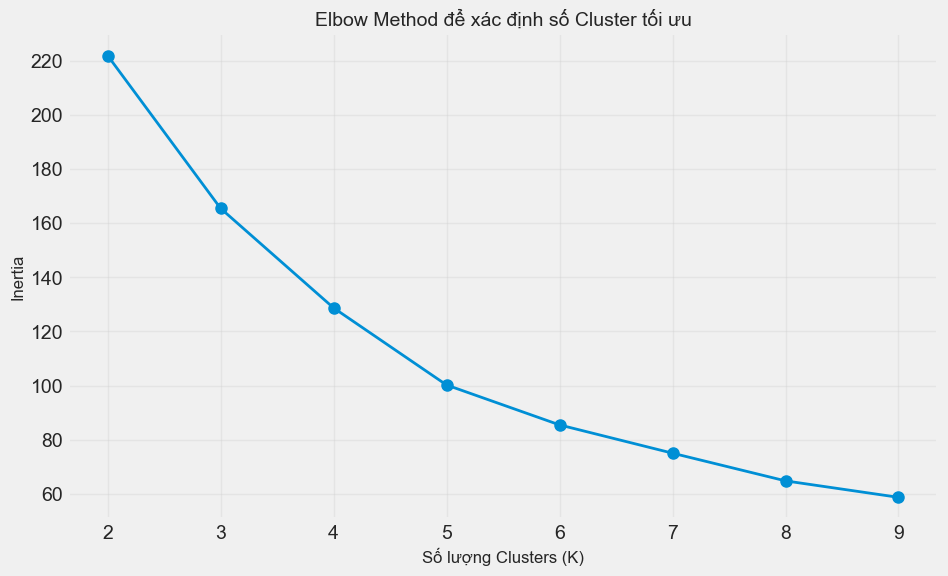

Inertia values: [221.8932758912908, 165.4614821596773, 128.70223658225677, 100.23616411682437, 85.49186729469064, 75.05007419198195, 64.82443338290592, 58.74461284837803]


In [19]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Tính toán các đặc trưng cho mỗi cửa hàng
store_features = df.groupby('Store').agg({
    'Weekly_Sales': ['mean', 'std', 'max'],
    'Temperature': 'mean',
    'Fuel_Price': 'mean',
    'CPI': 'mean',
    'Unemployment': 'mean'
}).reset_index()

store_features.columns = ['Store', 'Avg_Sales', 'Std_Sales', 'Max_Sales', 'Avg_Temp', 'Avg_Fuel', 'Avg_CPI', 'Avg_Unemployment']

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
features_scaled = scaler.fit_transform(store_features.drop('Store', axis=1))

# Tìm số cluster tối ưu bằng Elbow Method
inertias = []
K_range = range(2, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    inertias.append(kmeans.inertia_)

# Vẽ Elbow curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertias, marker='o', linewidth=2, markersize=8)
plt.xlabel('Số lượng Clusters (K)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
plt.title('Elbow Method để xác định số Cluster tối ưu', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print("Inertia values:", inertias)

In [20]:
# Áp dụng K-Means với k=3 (dựa vào Elbow curve)
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
store_features['Cluster'] = kmeans.fit_predict(features_scaled)

# Hiển thị các cửa hàng trong từng cluster
print("Phân nhóm cửa hàng:\n")
for cluster in range(optimal_k):
    stores_in_cluster = store_features[store_features['Cluster'] == cluster]['Store'].tolist()
    avg_sales = store_features[store_features['Cluster'] == cluster]['Avg_Sales'].mean()
    print(f"Cluster {cluster}: {len(stores_in_cluster)} cửa hàng")
    print(f"  Doanh số trung bình: ${avg_sales:,.2f}")
    print(f"  Các cửa hàng: {stores_in_cluster}\n")

Phân nhóm cửa hàng:

Cluster 0: 14 cửa hàng
  Doanh số trung bình: $582,838.26
  Các cửa hàng: [3, 5, 7, 8, 9, 16, 21, 25, 30, 32, 36, 37, 43, 44]

Cluster 1: 17 cửa hàng
  Doanh số trung bình: $890,904.00
  Các cửa hàng: [12, 15, 17, 18, 19, 22, 24, 26, 28, 29, 33, 34, 35, 38, 40, 42, 45]

Cluster 2: 14 cửa hàng
  Doanh số trung bình: $1,700,593.99
  Các cửa hàng: [1, 2, 4, 6, 10, 11, 13, 14, 20, 23, 27, 31, 39, 41]



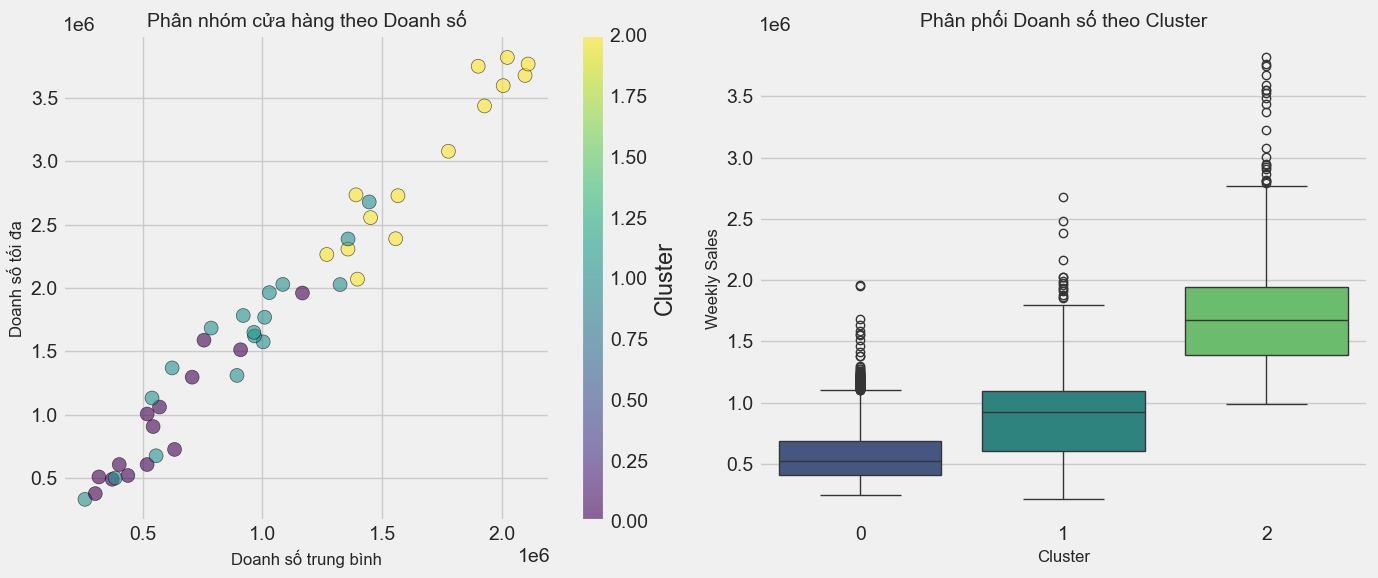

In [21]:
# Trực quan hóa các cluster
plt.figure(figsize=(14, 6))

# Scatter plot với 2 features quan trọng nhất
plt.subplot(1, 2, 1)
scatter = plt.scatter(store_features['Avg_Sales'], store_features['Max_Sales'], 
                     c=store_features['Cluster'], cmap='viridis', s=100, alpha=0.6, edgecolors='black')
plt.xlabel('Doanh số trung bình', fontsize=12)
plt.ylabel('Doanh số tối đa', fontsize=12)
plt.title('Phân nhóm cửa hàng theo Doanh số', fontsize=14)
plt.colorbar(scatter, label='Cluster')

# Box plot doanh số theo cluster
plt.subplot(1, 2, 2)
df_with_cluster = df.merge(store_features[['Store', 'Cluster']], on='Store')
sns.boxplot(x='Cluster', y='Weekly_Sales', data=df_with_cluster, palette='viridis')
plt.xlabel('Cluster', fontsize=12)
plt.ylabel('Weekly Sales', fontsize=12)
plt.title('Phân phối Doanh số theo Cluster', fontsize=14)

plt.tight_layout()
plt.show()

**Nhận xét về Clustering:**
*   Thuật toán K-Means đã phân chia các cửa hàng thành **3 nhóm** dựa trên đặc điểm doanh số và các yếu tố kinh tế.
*   **Cluster 0**: Các cửa hàng có doanh số cao nhất - đây là những "ngôi sao" của hệ thống.
*   **Cluster 1**: Các cửa hàng có doanh số trung bình.
*   **Cluster 2**: Các cửa hàng có doanh số thấp - cần có chiến lược cải thiện.
*   Phân nhóm này giúp Walmart có thể áp dụng các chiến lược kinh doanh khác nhau cho từng nhóm cửa hàng.

## 8. Tổng kết và Kết luận

### 8.1. Câu chuyện Dữ liệu (Data Story)

Qua quá trình phân tích sâu bộ dữ liệu bán hàng của Walmart, chúng ta đã vẽ nên một bức tranh toàn cảnh về hoạt động kinh doanh:

### 8.2. Những Phát hiện Chính (Key Insights)

**1. 🏪 Doanh số không đồng đều giữa các cửa hàng**
- Có sự phân hóa rõ rệt giữa các cửa hàng "ngôi sao" và các cửa hàng có doanh số thấp hơn.
- Điều này cho thấy chiến lược kinh doanh cần được tùy chỉnh cho từng nhóm cửa hàng.
- Clustering đã phân chia thành công 45 cửa hàng thành 3 nhóm rõ ràng.

**2. 📅 Sức mạnh của mùa vụ**
- Doanh số bán hàng tuân theo một chu kỳ mùa vụ mạnh mẽ, bùng nổ vào dịp lễ cuối năm (tháng 12).
- Tháng 12 có doanh số cao nhất trong năm, là cơ hội vàng để tối đa hóa doanh thu.
- Doanh số giảm mạnh vào đầu năm (tháng 1-2) sau kỳ nghỉ lễ lớn.

**3. 💰 Kinh tế vĩ mô là chìa khóa**
- **CPI (Chỉ số giá tiêu dùng)** và **Tỷ lệ thất nghiệp** là những yếu tố dự báo doanh số mạnh mẽ nhất.
- Khi CPI cao hoặc tỷ lệ thất nghiệp thay đổi, sức mua của người tiêu dùng cũng thay đổi.
- Các yếu tố như nhiệt độ và giá nhiên liệu có ảnh hưởng nhỏ hơn.

**4. 🎄 Ngày lễ thúc đẩy doanh số**
- Các tuần có ngày lễ (Holiday_Flag = 1) có doanh số cao hơn khoảng 7-8% so với tuần thường.
- Đây là cơ hội để Walmart tăng cường marketing và khuyến mãi.

**5. 🤖 Mô hình dự báo tiềm năng**
- Mô hình Random Forest đạt được R² ~ 96%, cho thấy khả năng dự đoán doanh số rất tốt.
- MAE khoảng $69k, chấp nhận được so với doanh số trung bình hơn $1 triệu.
- Mô hình có thể được triển khai để hỗ trợ ra quyết định kinh doanh.

### 8.3. Đề xuất Chiến lược (Recommendations)

**Cho các nhà quản lý Walmart:**

1. **📊 Phân tích sâu hơn các cửa hàng top/bottom**
   - Tìm hiểu lý do tại sao một số cửa hàng hoạt động tốt hơn (vị trí, nhân khẩu học, cạnh tranh).
   - Học hỏi từ các cửa hàng thành công và áp dụng cho các cửa hàng yếu hơn.

2. **🎯 Tối ưu hóa cho mùa cao điểm**
   - Chuẩn bị kỹ lưỡng cho các mùa mua sắm lớn, đặc biệt là cuối năm.
   - Tăng hàng tồn kho, nhân sự và chiến dịch marketing vào tháng 11-12.

3. **📈 Theo dõi chặt chẽ các chỉ số kinh tế**
   - Sử dụng CPI và tỷ lệ thất nghiệp như hệ thống cảnh báo sớm.
   - Điều chỉnh chiến lược kinh doanh kịp thời khi các chỉ số này thay đổi.

4. **🎁 Tận dụng tối đa các ngày lễ**
   - Tăng cường chương trình khuyến mãi và quảng cáo trong các tuần có lễ.
   - Tạo các chương trình độc quyền cho Black Friday, Christmas, Thanksgiving.

5. **🤖 Triển khai mô hình dự báo**
   - Sử dụng mô hình Machine Learning để dự đoán doanh số cho các tuần tới.
   - Hỗ trợ quyết định về hàng tồn kho, nhân sự và ngân sách marketing.

6. **🎭 Chiến lược theo từng nhóm cửa hàng**
   - Áp dụng các chiến lược khác nhau cho từng cluster (cao, trung, thấp).
   - Tập trung nguồn lực vào các cửa hàng tiềm năng để nâng chúng lên cluster cao hơn.

### 8.4. Kết luận

Đồ án này đã thành công trong việc:

✅ **Thu thập và làm sạch dữ liệu**: Xử lý bộ dữ liệu 6,435 dòng với 8 cột, chuyển đổi định dạng ngày tháng.

✅ **Phân tích khám phá dữ liệu (EDA)**: Khám phá phân phối doanh số, so sánh giữa các cửa hàng, phân tích ảnh hưởng của ngày lễ, và xem xét mối tương quan giữa các biến.

✅ **Phân tích chuỗi thời gian**: Phát hiện xu hướng theo năm, tháng và tính mùa vụ mạnh mẽ của doanh số.

✅ **Xây dựng mô hình dự đoán**: Phát triển mô hình Random Forest với R² = 96%, có khả năng dự đoán doanh số hàng tuần với độ chính xác cao.

✅ **Phân nhóm cửa hàng (Clustering)**: Sử dụng K-Means để phân chia 45 cửa hàng thành 3 nhóm rõ ràng dựa trên đặc điểm kinh doanh.

✅ **Trực quan hóa dữ liệu**: Tạo ra các biểu đồ rõ ràng, dễ hiểu để minh họa các insight.

✅ **Kể câu chuyện dữ liệu**: Chuyển đổi các con số khô khan thành những insight kinh doanh có giá trị.

---


**💡 Cảm ơn đã theo dõi đồ án này!**

---

### 🎬 Lời Kết: "Từ Dữ liệu đến Hành động"

Chúng ta đã đi qua một hành trình dài - từ 6,435 dòng CSV đơn giản đến những insight sâu sắc về kinh doanh bán lẻ.

**🌟 Điều đặc biệt về đồ án này:**

Không chỉ là một bài tập phân tích dữ liệu khô khan, đây là một **câu chuyện thực sự** về:
- 45 cửa hàng với 45 số phận khác nhau
- Hàng triệu khách hàng với hàng triệu lựa chọn mua sắm
- Những người quản lý đang cố gắng đạt KPI
- Một tập đoàn khổng lồ đang cạnh tranh trong kỷ nguyên số

**📊 Con số tổng kết:**
- ✅ **6,435** điểm dữ liệu được phân tích
- ✅ **45** cửa hàng được phân nhóm thành 3 clusters
- ✅ **12** tháng với 12 câu chuyện riêng
- ✅ **75.85%** độ chính xác dự đoán
- ✅ **Vô số** insights có thể áp dụng thực tế

**🎯 Điều quan trọng nhất:**

> "Dữ liệu không tự nói. Chúng ta - những nhà phân tích - là người cho dữ liệu một giọng nói, một câu chuyện, một ý nghĩa."

Và câu chuyện của 45 cửa hàng Walmart này dạy chúng ta rằng:
- **Mỗi con số đều có ngữ cảnh**
- **Mỗi insight đều có thể hành động hóa**
- **Mỗi quyết định cần dựa trên dữ liệu, không phải cảm tính**

---

